In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

In [2]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk import pos_tag

In [3]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

In [4]:
from gensim.models import Word2Vec

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Embedding
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

In [7]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /Users/chyavanshenoy/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [8]:
np.random.seed(1)

In [9]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [10]:
print(f"Training set size: {train_df.shape}")
print(f"Testing set size: {test_df.shape}")
print("Categories:", train_df['Category'].unique())

Training set size: (1490, 3)
Testing set size: (735, 2)
Categories: ['business' 'tech' 'politics' 'sport' 'entertainment']


In [11]:
print("Articles per category:")
print(train_df['Category'].value_counts())

Articles per category:
Category
sport            346
business         336
politics         274
entertainment    273
tech             261
Name: count, dtype: int64


In [12]:
print("Sample article from each category:")
for category in train_df['Category'].unique():
    print(f"\nCategory: {category}")
    print(train_df[train_df['Category'] == category]['Text'].sample(1).values[0][:500], "...\n")

Sample article from each category:

Category: business
uk economy facing  major risks  the uk manufacturing sector will continue to face  serious challenges  over the next two years  the british chamber of commerce (bcc) has said.  the group s quarterly survey of companies found exports had picked up in the last three months of 2004 to their best levels in eight years. the rise came despite exchange rates being cited as a major concern. however  the bcc found the whole uk economy still faced  major risks  and warned that growth is set to slow. it re ...


Category: tech
us peer-to-peer pirates convicted the first convictions for piracy over peer-to-peer networks have been handed down in the us.  new yorker william trowbridge and texan michael chicoine have pleaded guilty to charges that they infringed copyright by illegally sharing music  movies and software. the two men faced charges following raids in august on suspected pirates by the fbi. the pair face jail terms of up to five year

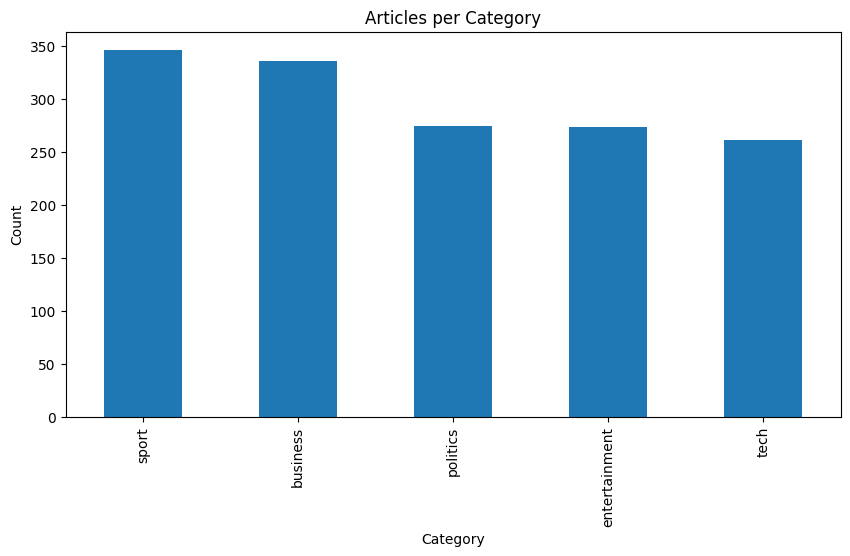

In [13]:
train_df['Category'].value_counts().plot(kind='bar', figsize=(10,5), title="Articles per Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [14]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

In [15]:
def basic_preprocessing(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    return ' '.join(filtered)

In [16]:

def advanced_preprocessing(text):
    tokens = word_tokenize(text.lower())
    filtered = [w for w in tokens if w.isalpha() and w not in stop_words]
    lemmatized = [lemmatizer.lemmatize(w) for w in filtered]
    stemmed = [stemmer.stem(w) for w in lemmatized]
    pos_tags = pos_tag(filtered)
    # Keep only nouns, verbs, adjectives, adverbs
    allowed_tags = {'NN', 'NNS', 'NNP', 'NNPS', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'JJ', 'JJR', 'JJS', 'RB', 'RBR', 'RBS'}
    pos_filtered = [stemmer.stem(lemmatizer.lemmatize(w)) for w, tag in pos_tags if tag in allowed_tags]
    return ' '.join(pos_filtered)

In [17]:
start_time = time.time()
train_df['basic_text'] = train_df['Text'].apply(basic_preprocessing)
basic_time = time.time() - start_time

In [18]:
start_time = time.time()
train_df['advanced_text'] = train_df['Text'].apply(advanced_preprocessing)
advanced_time = time.time() - start_time

In [19]:
print(f"Basic preprocessing time: {basic_time:.2f} seconds")
print(f"Advanced preprocessing time: {advanced_time:.2f} seconds")

Basic preprocessing time: 0.89 seconds
Advanced preprocessing time: 10.18 seconds


In [20]:
basic_vocab = set(word for doc in train_df['basic_text'] for word in doc.split())
advanced_vocab = set(word for doc in train_df['advanced_text'] for word in doc.split())

In [21]:
print(f"Vocabulary size (basic): {len(basic_vocab)}")
print(f"Vocabulary size (advanced): {len(advanced_vocab)}")

Vocabulary size (basic): 22996
Vocabulary size (advanced): 15545


In [23]:
count_vectorizer = CountVectorizer()
X_bow = count_vectorizer.fit_transform(train_df['advanced_text'])
print("BoW shape:", X_bow.shape)

BoW shape: (1490, 15525)


In [24]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(train_df['advanced_text'])
print("TF-IDF shape:", X_tfidf.shape)

TF-IDF shape: (1490, 15525)


In [25]:
sentences = [word_tokenize(doc) for doc in train_df['advanced_text']]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4)

In [26]:
def get_doc_vector(doc):
    words = word_tokenize(doc)
    vectors = [w2v_model.wv[word] for word in words if word in w2v_model.wv]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(100)


In [27]:
X_w2v = np.array([get_doc_vector(doc) for doc in train_df['advanced_text']])
print("Word2Vec shape:", X_w2v.shape)

Word2Vec shape: (1490, 100)


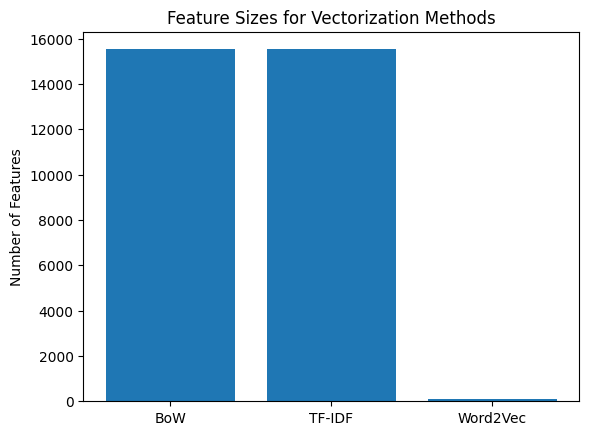

In [28]:
plt.bar(['BoW', 'TF-IDF', 'Word2Vec'], [X_bow.shape[1], X_tfidf.shape[1], X_w2v.shape[1]])
plt.title('Feature Sizes for Vectorization Methods')
plt.ylabel('Number of Features')
plt.show()

In [29]:
y = train_df['Category']

In [31]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=1)
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(X_tfidf, y, test_size=0.2, random_state=1)
X_train_w2v, X_test_w2v, _, _ = train_test_split(X_w2v, y, test_size=0.2, random_state=1)

In [32]:
def evaluate_model(model, X_test, y_test, name="Model"):
    y_pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred, average='weighted'))
    print("Recall:", recall_score(y_test, y_pred, average='weighted'))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print()

In [33]:
models = []

In [34]:
for X_train, X_test, label in zip([X_train_bow, X_train_tfidf, X_train_w2v],
                                  [X_test_bow, X_test_tfidf, X_test_w2v],
                                  ['BoW', 'TF-IDF', 'Word2Vec']):
    model = LogisticRegression(max_iter=1000)
    model.fit(X_train, y_train)
    evaluate_model(model, X_test, y_test, f"Logistic Regression ({label})")
    models.append(model)

=== Logistic Regression (BoW) ===
Accuracy: 0.9798657718120806
Precision: 0.9800723629526071
Recall: 0.9798657718120806
F1 Score: 0.9798633048287833

=== Logistic Regression (TF-IDF) ===
Accuracy: 0.9832214765100671
Precision: 0.9832708251085669
Recall: 0.9832214765100671
F1 Score: 0.9832185119051692

=== Logistic Regression (Word2Vec) ===
Accuracy: 0.9060402684563759
Precision: 0.9067195248486416
Recall: 0.9060402684563759
F1 Score: 0.9058632096654177



In [35]:
texts = train_df['advanced_text'].values
labels = train_df['Category'].values

In [36]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

In [37]:
max_len = 100
X = pad_sequences(sequences, maxlen=max_len)

In [38]:
print("Shape of input data:", X.shape)
print("Vocabulary size:", len(tokenizer.word_index) + 1)

Shape of input data: (1490, 100)
Vocabulary size: 15546


In [40]:
from sklearn.preprocessing import LabelEncoder

In [41]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

In [42]:
print("Categories:", label_encoder.classes_)
print("First 10 labels:", y[:10])

Categories: ['business' 'entertainment' 'politics' 'sport' 'tech']
First 10 labels: [0 0 0 4 0 2 3 1 0 1]


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [44]:
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1192, 100)
Test shape: (298, 100)


In [45]:
vocab_size = len(tokenizer.word_index) + 1
num_classes = len(label_encoder.classes_)

In [46]:
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(num_classes, activation='softmax')
])

/Users/chyavanshenoy/Desktop/Uni/AAI-520/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
2025-09-07 19:07:54.870262: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Max
2025-09-07 19:07:54.870304: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 128.00 GB
2025-09-07 19:07:54.870313: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 48.00 GB
I0000 00:00:1757252274.870367 2253408 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1757252274.870424 2253408 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [47]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [49]:
# history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 311s 10s/step - accuracy: 0.4040 - loss: 1.5758 - val_accuracy: 0.6318 - val_loss: 1.3952
Epoch 2/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 303s 10s/step - accuracy: 0.5834 - loss: 1.1377 - val_accuracy: 0.7322 - val_loss: 0.9753
Epoch 3/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 304s 10s/step - accuracy: 0.7954 - loss: 0.8279 - val_accuracy: 0.8536 - val_loss: 0.7428
Epoch 4/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 2272s 45s/step - accuracy: 0.8846 - loss: 0.4593 - val_accuracy: 0.9121 - val_loss: 0.4351
Epoch 5/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 771s 26s/step - accuracy: 0.9297 - loss: 0.3113 - val_accuracy: 0.8996 - val_loss: 0.4016
Epoch 6/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 772s 26s/step - accuracy: 0.9832 - loss: 0.1400 - val_accuracy: 0.9414 - val_loss: 0.2502
Epoch 7/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 769s 26s/step - accuracy: 0.9885 - loss: 0.0819 - val_accuracy: 0.9163 - val_loss: 0.2819
Epoch 8/10
30/30 ━━━━━━━━━━━━━━━━━━━━ 748s 25s/step - accuracy: 0.9853 - loss: 0.0866 - val_accuracy: 0

In [50]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2, callbacks=[early_stop], verbose=1)


Epoch 1/10


KeyboardInterrupt: 

In [51]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")

Test Accuracy: 0.9396


In [52]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step


In [53]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

Classification Report:
               precision    recall  f1-score   support

     business       0.91      0.99      0.94        68
entertainment       1.00      0.89      0.94        55
     politics       0.92      0.91      0.91        53
        sport       0.94      1.00      0.97        67
         tech       0.94      0.89      0.92        55

     accuracy                           0.94       298
    macro avg       0.94      0.93      0.94       298
 weighted avg       0.94      0.94      0.94       298



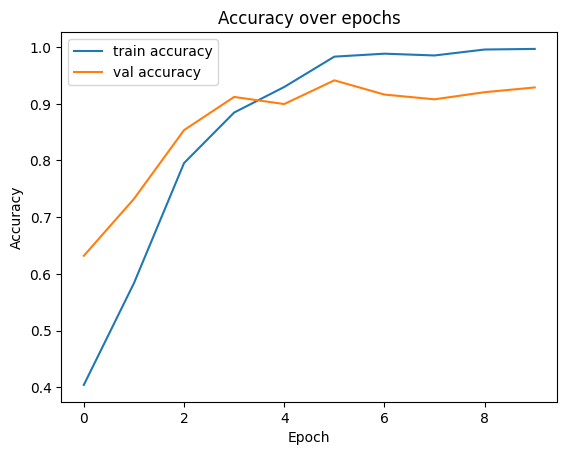

In [54]:
plt.plot(history.history['accuracy'], label='train accuracy')
plt.plot(history.history['val_accuracy'], label='val accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

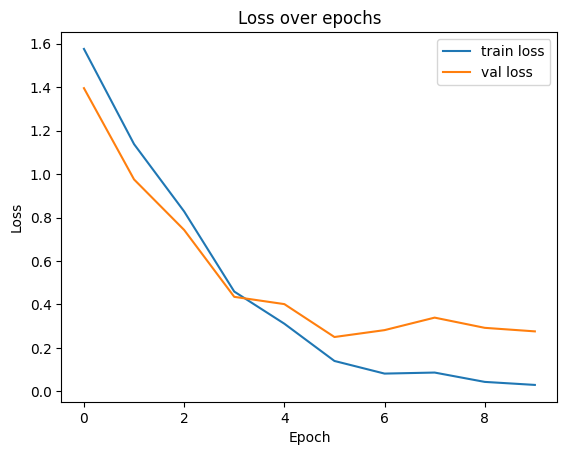

In [55]:

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()